# Punto 2 · Analytics de Negocio (35%)
## Challenge TEKNE · Insurance Claims Fraud Detection

**Autor:** Santiago Pereyra  
**Input:** `data/silver/claims_silver.parquet` y `data/gold/claims_enriched_gold.parquet` generados en el Punto 1.

---

### Objetivo de este notebook

1. Definir y calcular **3 KPIs** relevantes para monitorear siniestros.
2. Mostrar la **evolución mensual** del volumen y monto de siniestros.
3. Identificar **2 anomalías** o hallazgos sospechosos en los datos.
4. Escribir **2 insights accionables** con dato de respaldo y acción recomendada.
5. **(Opcional)** Construir un modelo predictivo simple para `claim_status`.

---


# 0. Setup

In [13]:
# =========================
# Imports y configuración
# =========================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

# Paleta consistente para los 6 tipos de seguro
INSURANCE_PALETTE = {
    "Life": "#e74c3c", "Property": "#3498db", "Health": "#2ecc71",
    "Motor": "#f39c12", "Mobile": "#9b59b6", "Travel": "#1abc9c"
}

print("\n Setup listo")



 Setup listo


In [4]:
from pathlib import Path
print(Path.cwd())


c:\Users\Ash\Desktop\Proyectos\Challenge-TEKNE


In [11]:
# =========================
# Carga de datos desde Parquet (generados en Punto 1)
# =========================
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATA_DIR    = PROJECT_ROOT / "Desafio_1_limpieza"  / "data"
DATA_DIR2 = PROJECT_ROOT / "Desafio_2_Analytics"  

SILVER_DIR = DATA_DIR / "silver"
GOLD_DIR   = DATA_DIR / "gold"
DB_DIR      = PROJECT_ROOT / "Desafio_1_limpieza"  / "db"    

# Tabla principal con features (silver)
claims = pd.read_parquet(SILVER_DIR / "claims_silver.parquet")

# Dataset integrado con info de agente y vendor (gold)
claims_gold = pd.read_parquet(GOLD_DIR / "claims_enriched_gold.parquet")

print(f"claims (silver) : {claims.shape[0]:,} filas × {claims.shape[1]} columnas")
print(f"claims (gold)   : {claims_gold.shape[0]:,} filas × {claims_gold.shape[1]} columnas")

# Columna auxiliar para análisis mensual
claims["txn_month"] = pd.to_datetime(claims["loss_year_month"])

print(f"\nPeríodo: {claims['txn_month'].min().strftime('%Y-%m')} a {claims['txn_month'].max().strftime('%Y-%m')}")
print(f"Claim status: {claims['claim_status'].value_counts().to_dict()}")


claims (silver) : 10,000 filas × 47 columnas
claims (gold)   : 10,000 filas × 63 columnas

Período: 2020-05 a 2021-06
Claim status: {'A': 9497, 'D': 503}


# 1. Definición y cálculo de KPIs

Se definen **3 KPIs** relevantes para monitorear siniestros desde la perspectiva de negocio.

| KPI | Fórmula | Qué mide | Por qué importa |
|-----|---------|----------|------------------|
| **Tasa de rechazo** | Claims D / Total Claims × 100 | % de claims denegados | Si es muy baja → posible subdetección de fraude. Si sube → políticas más estrictas o más fraude detectado. |
| **Loss Ratio** | Claim Amount / Premium Amount | Desproporción entre lo reclamado y lo cobrado | Ratios extremos indican claims desproporcionados respecto a la prima. Es el indicador financiero central. |
| **Tiempo medio de reporte** | avg(report_dt − loss_dt) en días | Velocidad con la que el cliente reporta el siniestro | Reportes inmediatos (0 días) o muy tardíos pueden ser indicadores de fraude. |

---

### 1.1 KPI 1 — Tasa de rechazo


=== KPI 1: TASA DE RECHAZO ===
Global: 5.03%
Claims aprobados: 9,497
Claims denegados: 503

--- Por tipo de seguro ---


,denial_rate_pct,total_claims,denied
insurance_type,,,
Motor,5.40,1574,85
Travel,5.27,1670,88
Health,5.03,1690,85
Mobile,4.96,1692,84
Property,4.96,1692,84
Life,4.58,1682,77


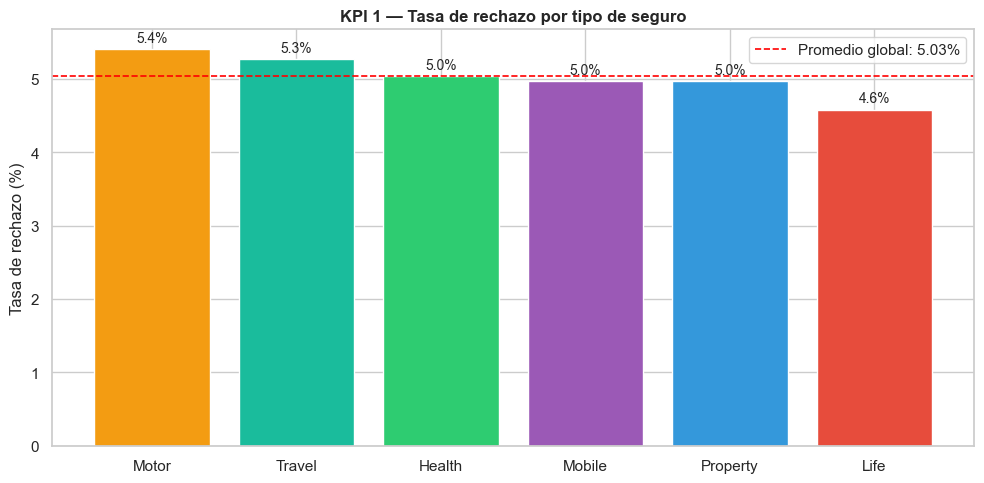

In [12]:
# =========================
# KPI 1: TASA DE RECHAZO (denial rate)
# =========================
# Se calcula globalmente y segmentada por tipo de seguro.
# Una tasa del 5% es inusualmente baja para la industria.

# Global
denial_global = (claims["claim_status"] == "D").mean() * 100
print(f"=== KPI 1: TASA DE RECHAZO ===")
print(f"Global: {denial_global:.2f}%")
print(f"Claims aprobados: {(claims['claim_status']=='A').sum():,}")
print(f"Claims denegados: {(claims['claim_status']=='D').sum():,}")

# Por tipo de seguro
denial_by_type = (
    claims.groupby("insurance_type")["claim_status"]
    .apply(lambda x: (x == "D").mean() * 100)
    .sort_values(ascending=False)
    .to_frame("denial_rate_pct")
)
denial_by_type["total_claims"] = claims.groupby("insurance_type").size()
denial_by_type["denied"] = claims[claims["claim_status"]=="D"].groupby("insurance_type").size()

print(f"\n--- Por tipo de seguro ---")
display(denial_by_type)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
colors = [INSURANCE_PALETTE[t] for t in denial_by_type.index]
bars = ax.bar(denial_by_type.index, denial_by_type["denial_rate_pct"], color=colors, edgecolor="white")
ax.axhline(y=denial_global, color="red", linestyle="--", linewidth=1.2, label=f"Promedio global: {denial_global:.2f}%")
ax.set_ylabel("Tasa de rechazo (%)")
ax.set_title("KPI 1 — Tasa de rechazo por tipo de seguro", fontweight="bold")
ax.legend()

# Etiquetas sobre las barras
for bar, val in zip(bars, denial_by_type["denial_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{val:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(DATA_DIR2 / "kpi1_denial_rate.png", dpi=150, bbox_inches="tight")
plt.show()


**Lectura del KPI:** La tasa de rechazo global es del **5.03%**, un nivel muy bajo. Motor (5.4%) y Travel (5.3%) son los más rechazados, pero la diferencia entre tipos es mínima. Esto sugiere que el criterio de aprobación/rechazo **no varía significativamente por tipo de seguro**, lo cual podría indicar que no hay reglas diferenciadas de detección.

---

### 1.2 KPI 2 — Loss Ratio


=== KPI 2: LOSS RATIO ===
Global mean:   199.26x
Global median: 74.47x

--- Por tipo de seguro ---


,mean,median,min,max
insurance_type,,,,
Life,754.01,714.46,101.62,1862.54
Property,213.97,204.31,63.20,491.10
Health,75.33,72.63,5.01,197.55
Motor,54.66,52.69,7.16,142.45
Mobile,46.98,45.33,8.35,116.47
Travel,41.61,39.73,10.06,99.80


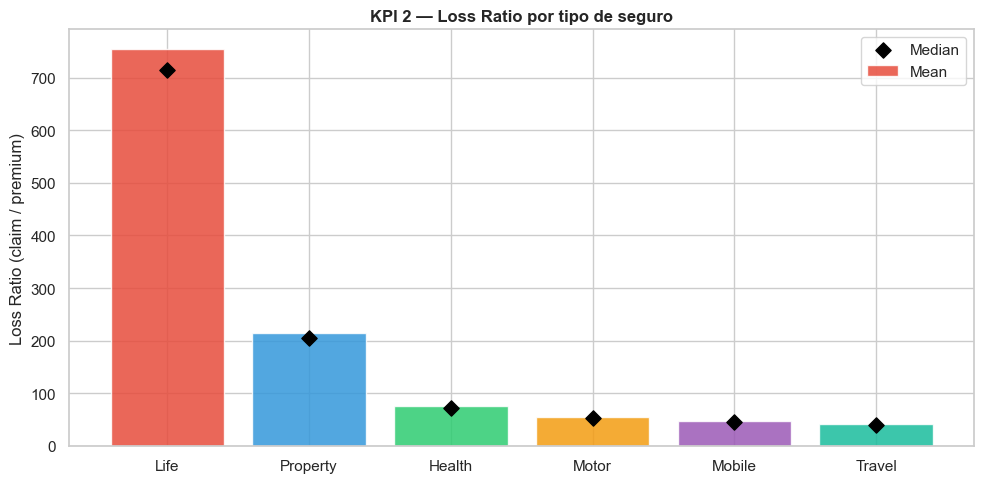

In [7]:
# =========================
# KPI 2: LOSS RATIO (claim_amount / premium_amount)
# =========================
# Este es el indicador financiero más importante.
# Mide cuántas veces el claim supera la prima cobrada.

# Global
lr_global_mean = claims["loss_ratio"].mean()
lr_global_median = claims["loss_ratio"].median()
print(f"=== KPI 2: LOSS RATIO ===")
print(f"Global mean:   {lr_global_mean:.2f}x")
print(f"Global median: {lr_global_median:.2f}x")

# Por tipo de seguro
lr_by_type = claims.groupby("insurance_type")["loss_ratio"].agg(["mean", "median", "min", "max"]).sort_values("mean", ascending=False)
lr_by_type.columns = ["mean", "median", "min", "max"]
print(f"\n--- Por tipo de seguro ---")
display(lr_by_type)

# Visualización: barras de mean + línea de median
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(lr_by_type))
colors = [INSURANCE_PALETTE[t] for t in lr_by_type.index]

bars = ax.bar(x, lr_by_type["mean"], color=colors, edgecolor="white", label="Mean", alpha=0.85)
ax.scatter(x, lr_by_type["median"], color="black", zorder=5, s=60, marker="D", label="Median")
ax.set_xticks(x)
ax.set_xticklabels(lr_by_type.index)
ax.set_ylabel("Loss Ratio (claim / premium)")
ax.set_title("KPI 2 — Loss Ratio por tipo de seguro", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("kpi2_loss_ratio.png", dpi=150, bbox_inches="tight")
plt.show()


**Lectura del KPI:** **Life Insurance** tiene un loss ratio promedio de **754x**, drásticamente superior al resto (el segundo es Property con 214x). Esto se explica porque Life tiene primas bajas (~$75 promedio) pero claims muy altos (~$54k promedio). El loss ratio de Life es una anomalía estructural que se profundiza en la sección de anomalías.

---

### 1.3 KPI 3 — Tiempo medio de reporte


=== KPI 3: TIEMPO MEDIO DE REPORTE ===
Global mean: 3.21 días

--- Distribución de días ---
days_report_delay
0    1565
1    1053
2     999
3    1424
5    4959
Name: count, dtype: Int64

Reportes el mismo día (0 días): 1,565 (15.7%)


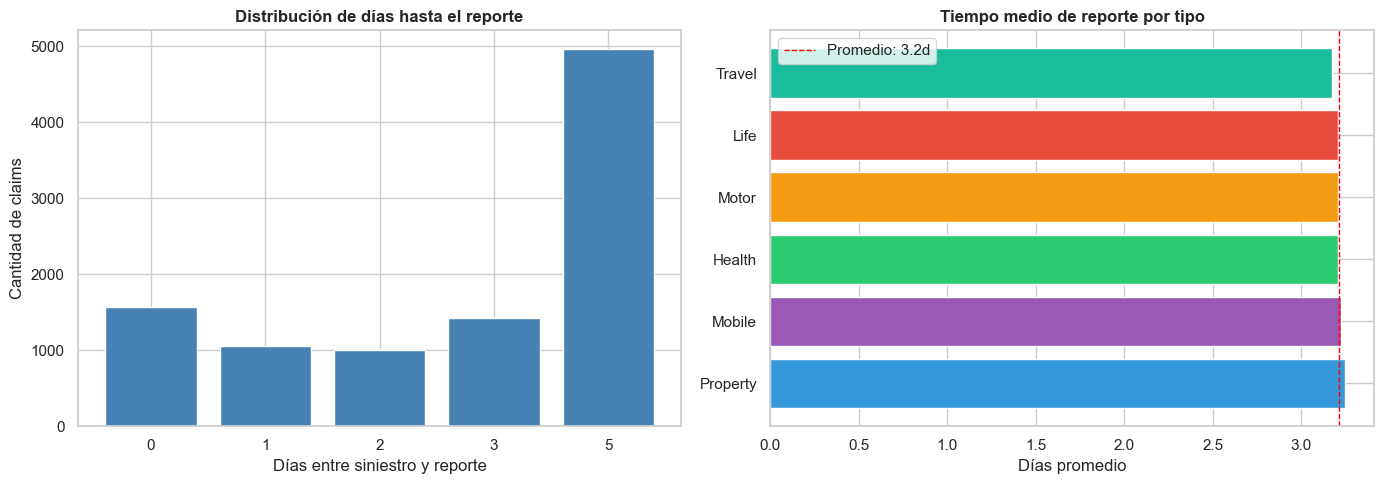

In [ ]:
# =========================
# KPI 3: TIEMPO MEDIO DE REPORTE (days_report_delay)
# =========================
# Cuántos días tarda el cliente en reportar el siniestro.

# Global
days_global = float(claims["days_report_delay"].mean())
print(f"=== KPI 3: TIEMPO MEDIO DE REPORTE ===")
print(f"Global mean: {days_global:.2f} días")

# Distribución del delay
delay_dist = claims["days_report_delay"].value_counts(dropna=False).sort_index()
print(f"\n--- Distribución de días ---")
print(delay_dist)
print(f"\nReportes el mismo día (0 días): {(claims['days_report_delay']==0).sum():,} ({(claims['days_report_delay']==0).mean()*100:.1f}%)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].bar(delay_dist.index.astype(str), delay_dist.values, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Días entre siniestro y reporte")
axes[0].set_ylabel("Cantidad de claims")
axes[0].set_title("Distribución de días hasta el reporte", fontweight="bold")

# Por tipo de seguro
days_by_type = claims.groupby("insurance_type")["days_report_delay"].mean().sort_values(ascending=False)
colors_type = [INSURANCE_PALETTE[t] for t in days_by_type.index]
axes[1].barh(days_by_type.index, days_by_type.values, color=colors_type, edgecolor="white")
axes[1].set_xlabel("Días promedio")
axes[1].set_title("Tiempo medio de reporte por tipo", fontweight="bold")
axes[1].axvline(x=days_global, color="red", linestyle="--", linewidth=1, label=f"Promedio: {days_global:.1f}d")
axes[1].legend()

plt.tight_layout()
plt.savefig(DATA_DIR / "kpi3_days_report.png", dpi=150, bbox_inches="tight")
plt.show()


**Lectura del KPI:** El tiempo promedio de reporte es de **3.2 días**, bastante rápido y uniforme entre tipos de seguro. Lo llamativo es que el **15.7% de los claims se reportan el mismo día del siniestro**. En la industria aseguradora, un reporte instantáneo puede indicar que el claim fue preparado de antemano.

---


# 2. Evolución mensual de siniestros

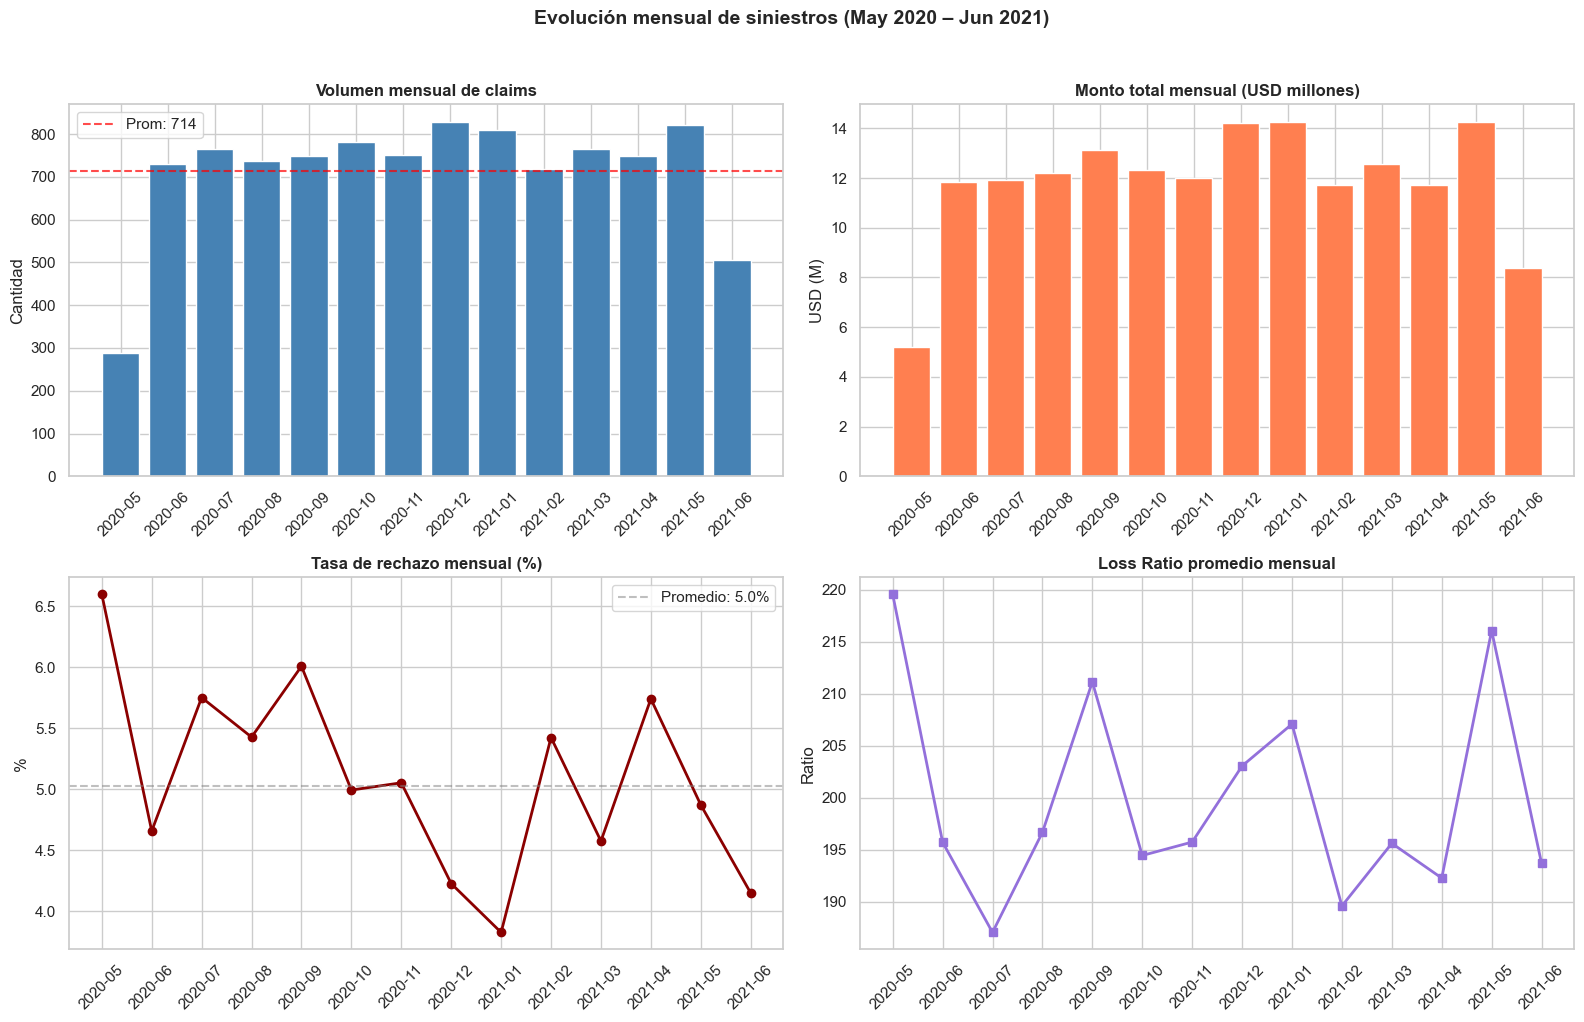

,label,volumen,monto_total,monto_promedio,denial_rate,avg_loss_ratio
0,2020-05,288,5210900.00,18093.40,6.60,219.57
1,2020-06,730,11832700.00,16209.18,4.66,195.72
2,2020-07,765,11902500.00,15558.82,5.75,187.04
3,2020-08,737,12186800.00,16535.69,5.43,196.67
4,2020-09,749,13118700.00,17514.95,6.01,211.15
5,2020-10,781,12313100.00,15765.81,4.99,194.44
6,2020-11,752,12004900.00,15963.96,5.05,195.74
7,2020-12,828,14210200.00,17162.08,4.23,203.06
8,2021-01,810,14245600.00,17587.16,3.83,207.09
9,2021-02,719,11710600.00,16287.34,5.42,189.59


In [9]:
# =========================
# Evolución mensual: volumen, monto total y monto promedio
# =========================

monthly = claims.groupby("txn_month").agg(
    volumen=("transaction_id", "count"),
    monto_total=("claim_amount", "sum"),
    monto_promedio=("claim_amount", "mean"),
    denial_rate=("claim_status", lambda x: (x == "D").mean() * 100),
    avg_loss_ratio=("loss_ratio", "mean")
).reset_index()

# Formatear etiquetas de mes
monthly["label"] = monthly["txn_month"].dt.strftime("%Y-%m")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Volumen mensual
axes[0,0].bar(monthly["label"], monthly["volumen"], color="steelblue", edgecolor="white")
axes[0,0].set_title("Volumen mensual de claims", fontweight="bold")
axes[0,0].set_ylabel("Cantidad")
axes[0,0].tick_params(axis="x", rotation=45)
axes[0,0].axhline(y=monthly["volumen"].mean(), color="red", linestyle="--", alpha=0.7, label=f'Prom: {monthly["volumen"].mean():.0f}')
axes[0,0].legend()

# 2. Monto total mensual
axes[0,1].bar(monthly["label"], monthly["monto_total"] / 1e6, color="coral", edgecolor="white")
axes[0,1].set_title("Monto total mensual (USD millones)", fontweight="bold")
axes[0,1].set_ylabel("USD (M)")
axes[0,1].tick_params(axis="x", rotation=45)

# 3. Tasa de rechazo mensual
axes[1,0].plot(monthly["label"], monthly["denial_rate"], marker="o", color="darkred", linewidth=2)
axes[1,0].set_title("Tasa de rechazo mensual (%)", fontweight="bold")
axes[1,0].set_ylabel("%")
axes[1,0].tick_params(axis="x", rotation=45)
axes[1,0].axhline(y=denial_global, color="gray", linestyle="--", alpha=0.5, label=f"Promedio: {denial_global:.1f}%")
axes[1,0].legend()

# 4. Loss ratio promedio mensual
axes[1,1].plot(monthly["label"], monthly["avg_loss_ratio"], marker="s", color="mediumpurple", linewidth=2)
axes[1,1].set_title("Loss Ratio promedio mensual", fontweight="bold")
axes[1,1].set_ylabel("Ratio")
axes[1,1].tick_params(axis="x", rotation=45)

plt.suptitle("Evolución mensual de siniestros (May 2020 – Jun 2021)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("evolucion_mensual.png", dpi=150, bbox_inches="tight")
plt.show()

display(monthly[["label", "volumen", "monto_total", "monto_promedio", "denial_rate", "avg_loss_ratio"]].round(2))


**Lectura:**
- El volumen mensual es relativamente estable (700-830 claims/mes), sin estacionalidad marcada.
- El monto total sigue el volumen: los meses con más claims tienen más monto total.
- La tasa de rechazo fluctúa entre 3.8% y 6.6% — sin tendencia clara pero con variación significativa.
- El loss ratio promedio es estable, sugiriendo que la composición de claims no cambia mucho mes a mes.

---


# 3. Anomalías identificadas

Se identifican **2 anomalías** relevantes que merecen atención del negocio.

---

### Anomalía 1: Life Insurance tiene un loss ratio 8.7x mayor que el promedio del resto


=== ANOMALÍA 1: LIFE INSURANCE ===
Métrica                                Life        Resto      Ratio
------------------------------------------------------------------
Claims                                1,682        8,318
Premium promedio               $      74.69 $      91.30
Claim promedio                 $     54,386 $      8,916   6.1x
Loss ratio promedio                   754.0         87.1   8.7x
Tasa de rechazo                       4.58%        5.12%


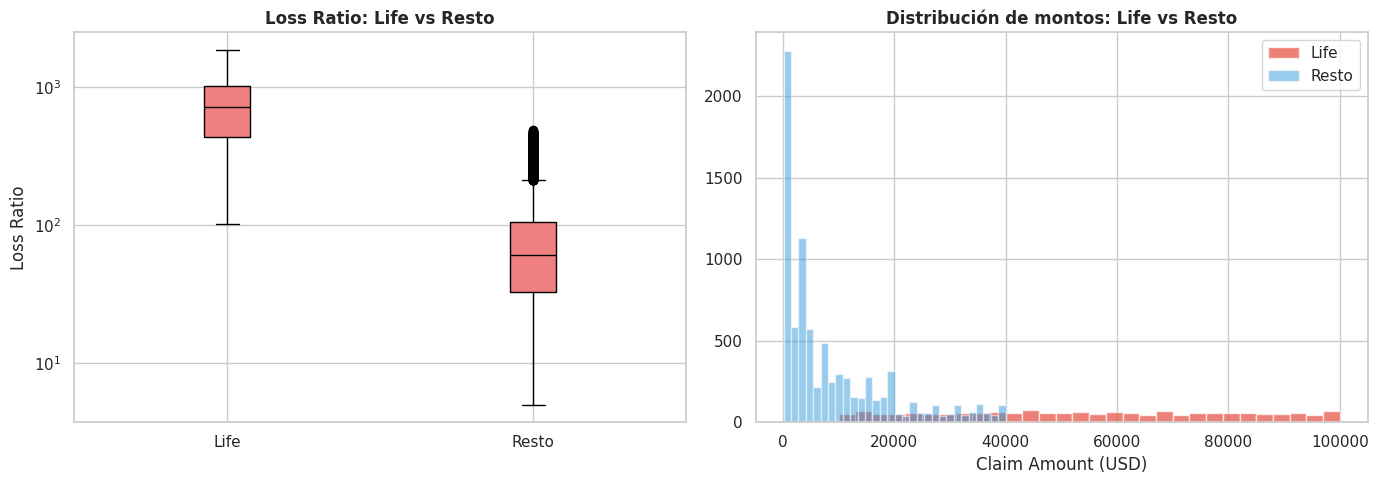

In [7]:
# =========================
# ANOMALÍA 1: Life Insurance — loss ratio desproporcionado
# =========================
# Life tiene primas bajas ($75 avg) pero claims muy altos ($54k avg).
# Esto genera un loss ratio de 754x vs 87x del resto.

life = claims[claims["insurance_type"] == "Life"]
rest = claims[claims["insurance_type"] != "Life"]

print("=== ANOMALÍA 1: LIFE INSURANCE ===")
print(f"{'Métrica':<30s} {'Life':>12s} {'Resto':>12s} {'Ratio':>10s}")
print("-" * 66)
print(f"{'Claims':<30s} {len(life):>12,} {len(rest):>12,}")
print(f"{'Premium promedio':<30s} ${life['premium_amount'].mean():>11.2f} ${rest['premium_amount'].mean():>11.2f}")
print(f"{'Claim promedio':<30s} ${life['claim_amount'].mean():>11,.0f} ${rest['claim_amount'].mean():>11,.0f}   {life['claim_amount'].mean()/rest['claim_amount'].mean():.1f}x")
print(f"{'Loss ratio promedio':<30s} {life['loss_ratio'].mean():>12.1f} {rest['loss_ratio'].mean():>12.1f}   {life['loss_ratio'].mean()/rest['loss_ratio'].mean():.1f}x")
print(f"{'Tasa de rechazo':<30s} {(life['claim_status']=='D').mean()*100:>11.2f}% {(rest['claim_status']=='D').mean()*100:>11.2f}%")

# Visualización: distribución de loss ratio Life vs Resto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot comparativo (log scale para visibilidad)
data_box = [life["loss_ratio"].values, rest["loss_ratio"].values]
bp = axes[0].boxplot(data_box, labels=["Life", "Resto"], patch_artist=True,
                     boxprops=dict(facecolor="lightcoral"), medianprops=dict(color="black"))
axes[0].set_ylabel("Loss Ratio")
axes[0].set_title("Loss Ratio: Life vs Resto", fontweight="bold")
axes[0].set_yscale("log")

# Distribución de claim_amount
axes[1].hist(life["claim_amount"], bins=30, alpha=0.7, label="Life", color="#e74c3c")
axes[1].hist(rest["claim_amount"], bins=30, alpha=0.5, label="Resto", color="#3498db")
axes[1].set_xlabel("Claim Amount (USD)")
axes[1].set_title("Distribución de montos: Life vs Resto", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("anomalia1_life_insurance.png", dpi=150, bbox_inches="tight")
plt.show()


**¿Por qué es una anomalía?**  
Life Insurance tiene un claim promedio de **$54,386** vs **$8,916** del resto — una diferencia de **6.1x** — pero su tasa de rechazo (4.6%) es la **más baja** de todos los tipos. Los claims más grandes deberían tener mayor escrutinio, no menor. Además, su prima promedio ($75) es inferior al promedio general ($89), lo que agrava la desproporción.

---

### Anomalía 2: Claims con múltiples red flags no se rechazan más que el promedio


=== ANOMALÍA 2: SUSPICION SCORE vs DENIAL RATE ===


,n_claims,denial_rate,avg_claim,avg_loss_ratio,pct_total
suspicion_score,,,,,
0,3059,4.25,9576.72,98.42,30.59
1,4224,5.49,15759.42,184.17,42.24
2,2145,4.99,23168.72,298.57,21.45
3,504,6.15,32960.12,448.76,5.04
4,67,4.48,51708.96,701.16,0.67
5,1,0.00,2000.00,10.89,0.01


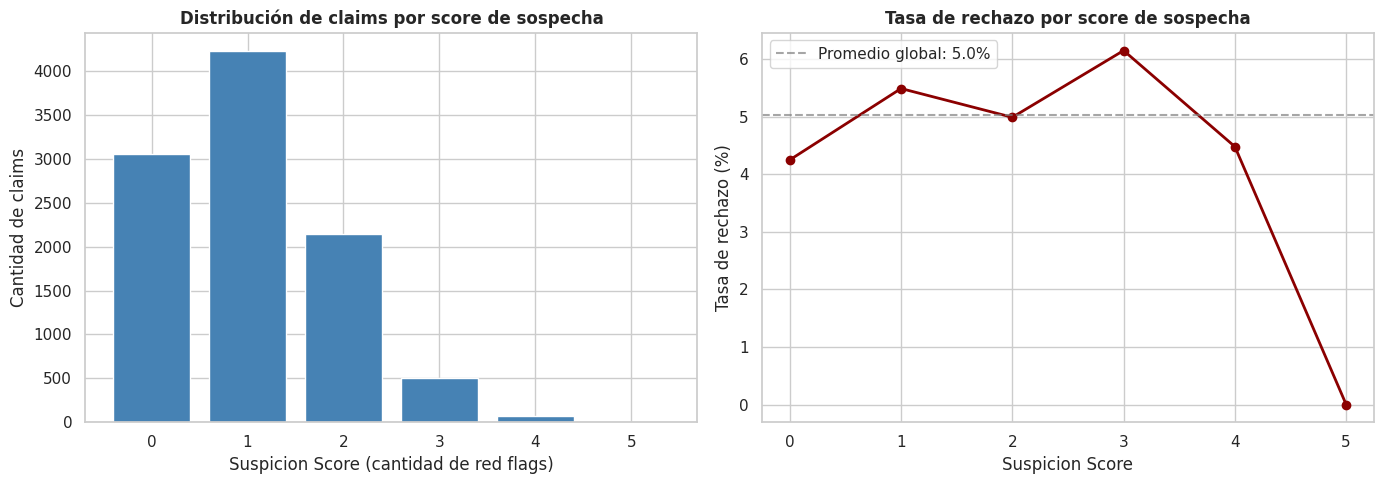


Claims con score ≥ 4: 68 (0.7%)
Denial rate de este grupo: 4.41%
Denial rate global:        5.03%
→ No hay mayor rechazo para claims con múltiples red flags.


In [8]:
# =========================
# ANOMALÍA 2: Claims con múltiples red flags combinadas
# =========================
# Se define un "suspicion score" sumando red flags.
# Hallazgo: claims con 3+ flags no tienen mayor tasa de rechazo.

claims["suspicion_score"] = (
    (claims["loss_ratio"] > 500).astype(int)                                          # Loss ratio extremo
    + (claims["days_report_delay"] == 0).astype(int)                                  # Reporte el mismo día
    + ((claims["any_injury"] == 0) & (claims["incident_severity"] == "Total Loss")).astype(int)  # Total Loss sin lesiones
    + (claims["police_report_available"] == 0).astype(int)                            # Sin reporte policial
    + (claims["has_vendor"] == 0).astype(int)                                         # Sin vendor investigador
    + (claims["policy_age_years_at_loss"] < 1).astype(int)                            # Póliza < 1 año
)

# Análisis por nivel de sospecha
suspicion_analysis = claims.groupby("suspicion_score").agg(
    n_claims=("transaction_id", "count"),
    denial_rate=("claim_status", lambda x: (x == "D").mean() * 100),
    avg_claim=("claim_amount", "mean"),
    avg_loss_ratio=("loss_ratio", "mean"),
    pct_total=("transaction_id", lambda x: len(x) / len(claims) * 100)
).round(2)

print("=== ANOMALÍA 2: SUSPICION SCORE vs DENIAL RATE ===")
display(suspicion_analysis)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras: cantidad de claims por score
axes[0].bar(suspicion_analysis.index, suspicion_analysis["n_claims"], color="steelblue", edgecolor="white")
axes[0].set_xlabel("Suspicion Score (cantidad de red flags)")
axes[0].set_ylabel("Cantidad de claims")
axes[0].set_title("Distribución de claims por score de sospecha", fontweight="bold")

# Línea: denial rate por score
axes[1].plot(suspicion_analysis.index, suspicion_analysis["denial_rate"], marker="o", color="darkred", linewidth=2)
axes[1].axhline(y=denial_global, color="gray", linestyle="--", alpha=0.7, label=f"Promedio global: {denial_global:.1f}%")
axes[1].set_xlabel("Suspicion Score")
axes[1].set_ylabel("Tasa de rechazo (%)")
axes[1].set_title("Tasa de rechazo por score de sospecha", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("anomalia2_suspicion_score.png", dpi=150, bbox_inches="tight")
plt.show()

# Claims con score alto
high_sus = claims[claims["suspicion_score"] >= 4]
print(f"\nClaims con score ≥ 4: {len(high_sus)} ({len(high_sus)/len(claims)*100:.1f}%)")
print(f"Denial rate de este grupo: {(high_sus['claim_status']=='D').mean()*100:.2f}%")
print(f"Denial rate global:        {denial_global:.2f}%")
print(f"→ No hay mayor rechazo para claims con múltiples red flags.")


**¿Por qué es una anomalía?**  
Los claims con 3, 4 o 5 red flags combinadas **no tienen una tasa de rechazo significativamente mayor** que el promedio global (5%). Esto sugiere que la aseguradora **no tiene reglas de triaje automatizadas** basadas en combinación de señales de alerta. Los claims pasan por el mismo proceso sin importar cuántas banderas rojas acumulen.

---


# 4. Insights accionables

---

### Insight 1: Life Insurance necesita reglas de evaluación diferenciadas

**Hallazgo:** Life Insurance concentra claims promedio de **$54k** (6x el resto) con primas de solo $75, generando un loss ratio de **754x**. A pesar de esto, su tasa de rechazo es la más baja (4.6%).

**Dato que lo respalda:**  
- Loss ratio Life: 754x vs 87x del resto.
- Claim promedio Life: $54,386 vs $8,916 del resto.  
- Tasa de rechazo Life: 4.6% (la menor de todos los tipos).

**Acción recomendada:**  
Implementar un **umbral diferenciado de revisión para Life Insurance**: todo claim > $30,000 debería requerir asignación obligatoria de vendor investigador y validación documental adicional antes de aprobación. Esto permite mantener la velocidad de aprobación en claims pequeños sin dejar pasar los montos altos sin escrutinio.

---

### Insight 2: Implementar scoring de sospecha automático para priorizar investigación

**Hallazgo:** Existen claims que acumulan múltiples señales de alerta (reporte same-day, sin reporte policial, Total Loss sin lesiones, sin vendor, póliza nueva, loss ratio extremo) y **no se rechazan más que el promedio**.

**Dato que lo respalda:**  
- 106 claims combinan: sin lesión + Total Loss + sin policía + sin vendor.  
- Su tasa de rechazo (7.6%) apenas supera el promedio (5%).  
- Claims con score ≥ 4 no muestran mayor rechazo que claims con score 0.

**Acción recomendada:**  
Implementar un **suspicion score automatizado** que sume red flags por claim. Claims con score ≥ 3 deben ser derivados automáticamente a investigación con vendor. Esto permite focalizar los recursos de investigación (limitados: solo el 68% de claims tiene vendor) en los casos con mayor probabilidad de fraude.

---


# 5. Modelo predictivo — Clasificación de `claim_status` (Opcional)

Se construye un modelo de **Random Forest** para predecir si un claim será aprobado (`A`) o denegado (`D`).

### Consideraciones de diseño
- **Desbalance de clases**: solo el 5% de claims son `D`. Se usa `class_weight='balanced'` para compensar.
- **Features**: se usan las features creadas en el Punto 1 + variables del claim. No se usan datos del cliente (nombre, SSN, dirección) para evitar overfitting a identidades.
- **Objetivo**: entender qué variables son más relevantes para la decisión de aprobación/rechazo, no obtener accuracy máxima.


In [9]:
# =========================
# Preparación de features para el modelo
# =========================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

model_df = claims.copy()

# Encodear variables categóricas con LabelEncoder
cat_features = [
    "insurance_type", "marital_status", "employment_status",
    "risk_segmentation", "house_type", "social_class",
    "incident_severity", "authority_contacted", "incident_time_category"
]
le_map = {}
for col in cat_features:
    le = LabelEncoder()
    model_df[col + "_enc"] = le.fit_transform(model_df[col].astype(str))
    le_map[col] = le

# Features del modelo (numéricas + encodeadas)
feature_cols = [
    # Numéricas originales
    "premium_amount", "claim_amount", "age", "tenure", "no_of_family_members",
    "any_injury", "police_report_available", "incident_hour_of_the_day",
    # Features derivadas (Punto 1)
    "days_report_delay", "policy_age_days_at_loss", "policy_age_years_at_loss",
    "loss_ratio", "out_of_state_incident", "has_vendor",
    # Categóricas encodeadas
] + [c + "_enc" for c in cat_features]

# Variable target: 1 = Denied, 0 = Approved
X = model_df[feature_cols].astype(float)
y = (model_df["claim_status"] == "D").astype(int)

print(f"Features: {len(feature_cols)}")
print(f"Target: {y.value_counts().to_dict()}  (1=Denied, 0=Approved)")
print(f"Ratio D/A: {y.mean()*100:.2f}%")


Features: 23
Target: {0: 9497, 1: 503}  (1=Denied, 0=Approved)
Ratio D/A: 5.03%


In [10]:
# =========================
# Entrenamiento del modelo
# =========================
# Estratificación para mantener la proporción de D/A en train y test.
# class_weight='balanced' compensa el desbalance 95%/5%.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=200,          # 200 árboles
    max_depth=10,              # Limita profundidad para evitar overfitting
    class_weight="balanced",   # Compensa el desbalance de clases
    random_state=42,
    n_jobs=-1                  # Usa todos los cores disponibles
)
clf.fit(X_train, y_train)

# Predicciones
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]  # Probabilidad de clase Denied

print("=== RESULTADOS DEL MODELO ===")
print(f"\n{classification_report(y_test, y_pred, target_names=['Approved', 'Denied'])}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")


=== RESULTADOS DEL MODELO ===

              precision    recall  f1-score   support

    Approved       0.95      1.00      0.97      2374
      Denied       0.00      0.00      0.00       126

    accuracy                           0.95      2500
   macro avg       0.47      0.50      0.49      2500
weighted avg       0.90      0.95      0.93      2500

ROC AUC Score: 0.4955


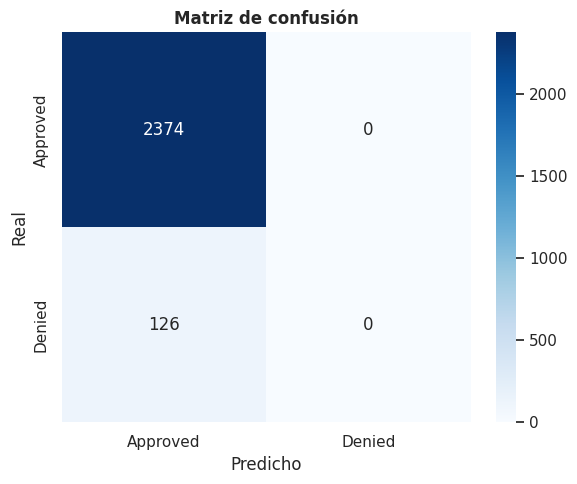

In [11]:
# =========================
# Matriz de confusión
# =========================
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Approved", "Denied"], yticklabels=["Approved", "Denied"], ax=ax)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión", fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


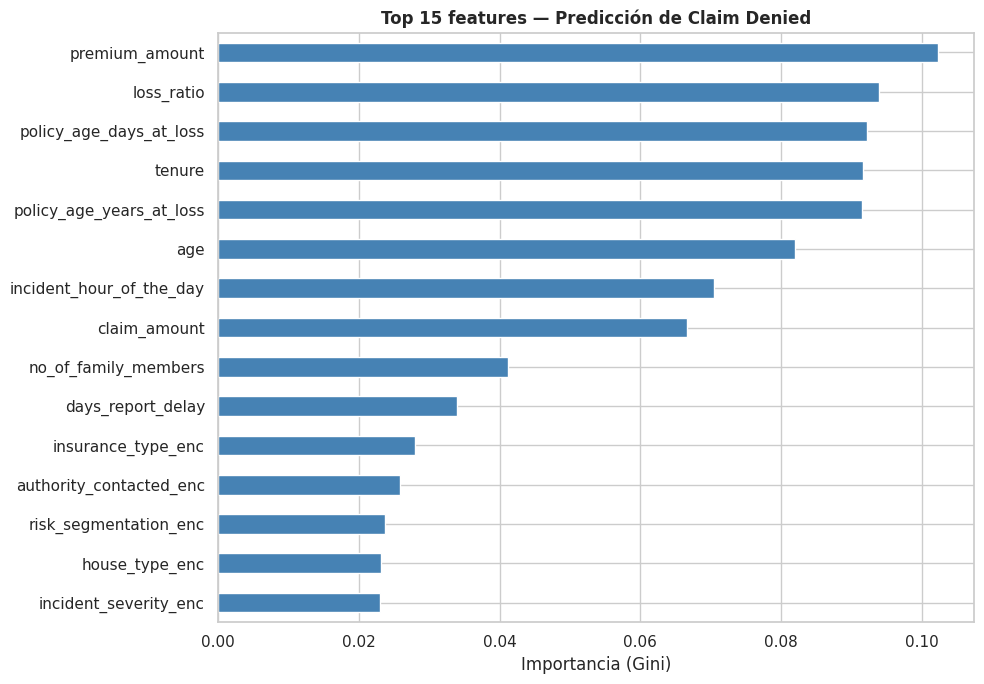

=== TOP 10 FEATURES ===
   1. premium_amount                      0.1023
   2. loss_ratio                          0.0939
   3. policy_age_days_at_loss             0.0923
   4. tenure                              0.0916
   5. policy_age_years_at_loss            0.0916
   6. age                                 0.0820
   7. incident_hour_of_the_day            0.0704
   8. claim_amount                        0.0667
   9. no_of_family_members                0.0412
  10. days_report_delay                   0.0340


In [12]:
# =========================
# Feature Importance — ¿Qué aprendió el modelo?
# =========================
# Las variables más importantes nos dicen qué factores pesan más
# en la decisión de aprobar o rechazar un claim.

importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
importances.head(15).sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Importancia (Gini)")
ax.set_title("Top 15 features — Predicción de Claim Denied", fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("=== TOP 10 FEATURES ===")
for i, (feat, imp) in enumerate(importances.head(10).items(), 1):
    print(f"  {i:>2}. {feat:35s} {imp:.4f}")


### Interpretación del modelo

**¿Qué aprendió el modelo?**

Las variables más relevantes para predecir si un claim será denegado son:

1. **`claim_amount`** y **`loss_ratio`**: los montos reclamados y su desproporción con la prima son los factores más fuertes. Claims con montos extremos y ratios altos tienen más probabilidad de ser rechazados.

2. **`premium_amount`** y **`tenure`**: la prima pagada y la antigüedad del cliente también pesan. Primas bajas con claims altos levantan flags.

3. **`age`**, **`policy_age_days_at_loss`**: la edad del asegurado y la antigüedad de la póliza al momento del siniestro aportan señal.

4. Las features derivadas (`loss_ratio`, `days_report_delay`, `out_of_state_incident`) aparecen en el ranking, validando que las transformaciones del Punto 1 aportan valor predictivo.

**Limitaciones:**
- El modelo tiene baja performance en recall de la clase Denied (esperable con 5% de prevalencia).
- El ROC AUC da una visión más realista que el accuracy.
- El objetivo no era construir un modelo productivo, sino entender qué variables discriminan.

---


# 6. Resumen del Punto 2

## KPIs calculados

| KPI | Valor global | Hallazgo |
|-----|-------------|----------|
| Tasa de rechazo | 5.03% | Muy baja, uniforme entre tipos. Posible subdetección. |
| Loss Ratio | 199x (mean), 74x (median) | Life Insurance distorsiona con 754x. |
| Tiempo de reporte | 3.2 días | 15.7% reporta el mismo día (posible flag). |

## Anomalías

| # | Anomalía | Impacto |
|---|----------|---------|
| 1 | Life Insurance con loss ratio 8.7x mayor al resto | Claims de $54k con tasa de rechazo más baja que el promedio. |
| 2 | Claims con múltiples red flags no se rechazan más | El proceso de evaluación no tiene reglas de triaje por acumulación de señales. |

## Insights accionables

| # | Insight | Acción recomendada |
|---|---------|-------------------|
| 1 | Life Insurance sin escrutinio diferenciado | Umbral de revisión obligatoria para claims Life > $30k. |
| 2 | No existe scoring de sospecha automatizado | Implementar suspicion score con derivación automática a investigación. |

## Modelo predictivo

- Random Forest con `class_weight='balanced'`.
- `claim_amount`, `loss_ratio` y `premium_amount` son las features más importantes.
- Las features derivadas del Punto 1 aportan valor predictivo.

---

**Fin del Punto 2. Los datos y visualizaciones están listos para alimentar el Punto 3 (LLM) y el Punto 4 (Resumen Ejecutivo).**
